In [1]:
import torch
import torchvision
import torchvision.transforms as transforms


In [3]:
transform=transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))]
)
batch_size=4
trainset=torchvision.datasets.CIFAR10(root='./data',train=True,download=False,
                                    transform=transform)
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,
                                       shuffle=True,num_workers=2)
testset=torchvision.datasets.CIFAR10(root='./data',train=False,download=False,
                                    transform=transform)
testloader=torch.utils.data.DataLoader(testset,batch_size=batch_size,
                                      shuffle=False,num_workers=2)
classes=('plane','car','bird','cat',
        'deer','dog','frog','horse','ship','truck')

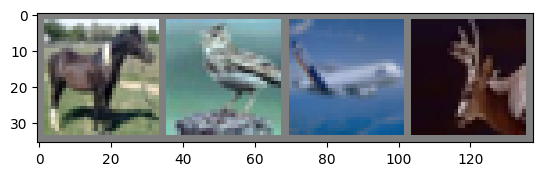

horse bird  plane deer 


In [10]:
import matplotlib.pyplot as plt
# from collections.abc import Iterator
import numpy as np
def imshow(img):
    img=img/2+0.5
    npimg=img.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.show()
dataiter = iter(trainloader)
images,labels=next(dataiter)
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

2.定义卷积神经网络

In [13]:
import torch.nn as nn
import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,6,5)
        self.pool=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(6,16,5)
        self.fc1=nn.Linear(16*5*5,120)
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)
    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))
        x=self.pool(F.relu(self.conv2(x)))
        x=torch.flatten(x,1)
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.fc3(x)
        return x
net=Net()

In [16]:
import torch.optim as optim
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(net.parameters(),lr=0.001,momentum=0.9)
for epoch in range(2):
    running_loss=0.0
    for i,data in enumerate(trainloader,0):
        inputs,labels=data
        optimizer.zero_grad()
        outputs=net(inputs)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
        if i%2000 == 1999:
            print(f'[{epoch+1},{i+1:5d}] loss:{running_loss/2000:.3f}')
            running_loss=0.0
print('Finished Training')

[1, 2000] loss:1.208
[1, 4000] loss:1.197
[1, 6000] loss:1.185
[1, 8000] loss:1.215
[1,10000] loss:1.194
[1,12000] loss:1.178
[2, 2000] loss:1.083
[2, 4000] loss:1.114
[2, 6000] loss:1.128
[2, 8000] loss:1.108
[2,10000] loss:1.114
[2,12000] loss:1.093
Finished Training


In [17]:
PATH='./cifar_net2.pth'
torch.save(net.state_dict(),PATH)

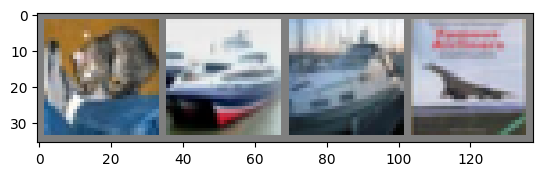

Ground Truth: cat   ship  ship  plane


In [18]:
dataiter=iter(testloader)
images,labels=next(dataiter)
imshow(torchvision.utils.make_grid(images))
print('Ground Truth:',' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [20]:
outputs=net(images)
_,predicted=torch.max(outputs,1)
print('Predicted:',' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))


Predicted: frog  ship  ship  ship 


In [25]:
correct=0
total=0
with torch.no_grad():
    for data in testloader:
        images,labels=data
        outputs=net(images)
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 59 %


In [27]:
correct_pred={classname:0 for classname in classes}
total_pred={classname:0 for classname in classes}
with torch.no_grad():
    for data in testloader:
        images,labels=data
        outputs=net(images)
        _,predictions=torch.max(outputs,1)
        for label,prediction in zip(labels,predictions):
            if label==prediction:
                correct_pred[classes[label]]+=1
            total_pred[classes[label]]+=1
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 71.4 %
Accuracy for class: car   is 76.0 %
Accuracy for class: bird  is 48.9 %
Accuracy for class: cat   is 34.9 %
Accuracy for class: deer  is 60.7 %
Accuracy for class: dog   is 43.7 %
Accuracy for class: frog  is 55.5 %
Accuracy for class: horse is 69.5 %
Accuracy for class: ship  is 80.4 %
Accuracy for class: truck is 51.2 %
